In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
from xgboost import XGBClassifier

sns.set_style("whitegrid")
%matplotlib inline

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [6]:
# These columns are either identifiers or constant across every row in this dataset
drop_cols = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df_model = df.drop(columns=drop_cols)

# Encode target
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

In [7]:
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


/var/folders/sx/tj734km91cqfjjxk7lpz0hlc0000gn/T/ipykernel_66195/4216046895.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_model.select_dtypes(include="object").columns.tolist()


In [8]:
X = df_model.drop(columns=["Attrition"])
y = df_model["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(1176, 30) (294, 30)


In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",   # dataset is imbalanced (~16% attrition)
    random_state=42
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [10]:
# scale_pos_weight helps XGBoost handle the same class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

In [11]:
def get_metrics(y_true, preds, probs, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1": f1_score(y_true, preds),
        "ROC AUC": roc_auc_score(y_true, probs)
    }

results = pd.DataFrame([
    get_metrics(y_test, rf_preds, rf_probs, "Random Forest"),
    get_metrics(y_test, xgb_preds, xgb_probs, "XGBoost")
])
results.set_index("Model").round(3)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Random Forest,0.830,0.465,0.426,0.444,0.787
XGBoost,0.833,0.474,0.383,0.424,0.778


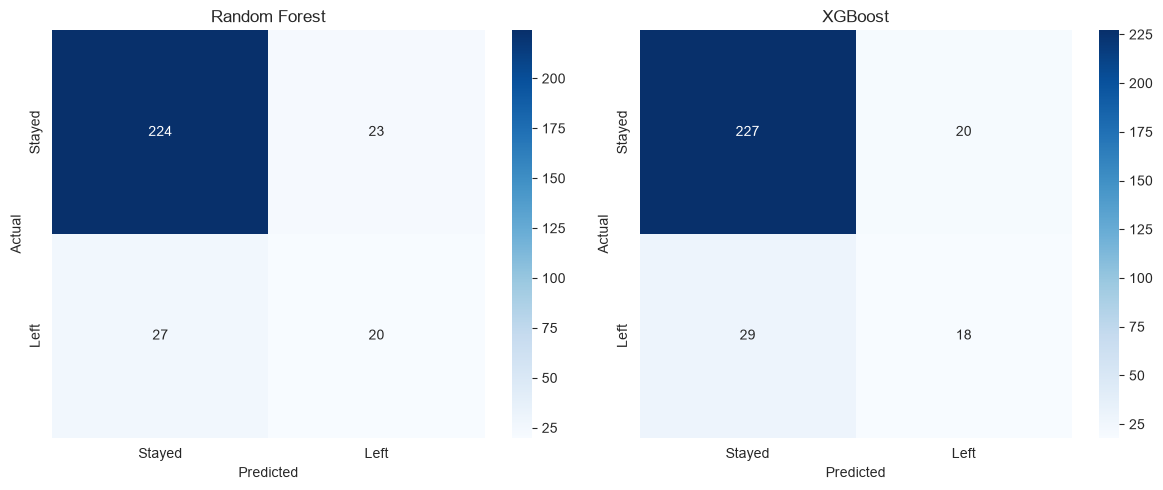

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name in zip(axes, [rf_preds, xgb_preds], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

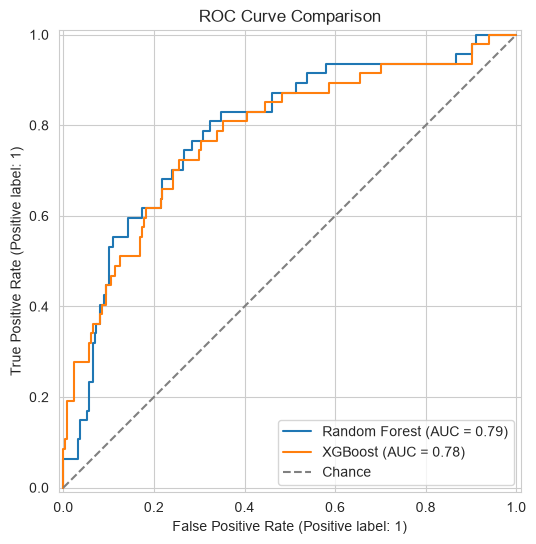

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, rf_probs, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, xgb_probs, name="XGBoost", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

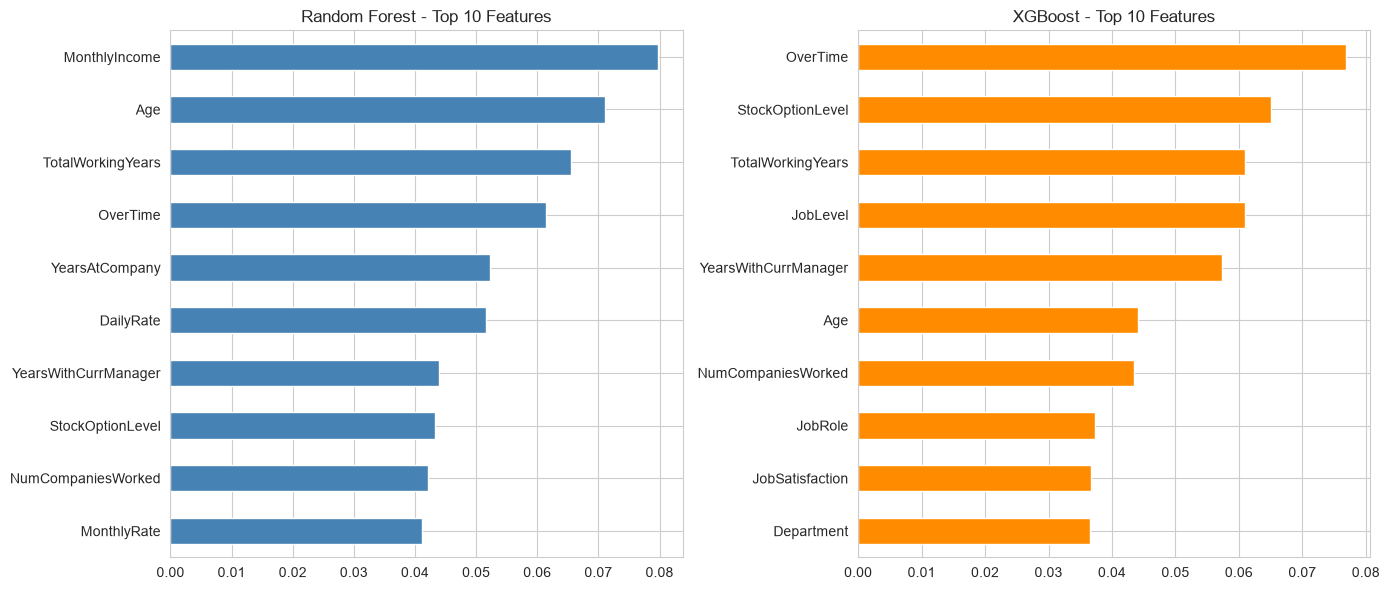

In [14]:
rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importance.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest - Top 10 Features")
axes[0].invert_yaxis()

xgb_importance.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost - Top 10 Features")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [16]:
import joblib

joblib.dump(rf, "rf_attrition_model.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Model and preprocessing artifacts saved to ../models/")

Model and preprocessing artifacts saved to ../models/
